In [ ]:
from pathlib import Path

DATA_DIR  = Path('path_to_preprocessed_data')
TRAIN_DIR = DATA_DIR / 'train'
VALID_DIR = DATA_DIR / 'valid'
TEST_DIR = DATA_DIR / 'test'
NOISE_DIR = DATA_DIR / '_background_noise_'

print("Train:", len(list(TRAIN_DIR.rglob('*.wav'))))
print("Valid:", len(list(VALID_DIR.rglob('*.wav'))))

Train: 51486
Valid: 6828


In [ ]:
import sys, os
REPO_PATH = 'path_to_repo'
sys.path.insert(0, REPO_PATH)
os.chdir(REPO_PATH) 

import numpy as np
import torch
from data.utils import get_datasets, precompute_features
from data.dataset import CachedDataset
from models.utils import set_seed
from models.logistic_regression import LogisticRegressionBaseline
from models.evaluate import evaluate
from plots import plot_confusion_matrix, plot_per_class_metrics

SEED = 0

In [7]:
train_ds, valid_ds, test_ds = get_datasets('mfcc_lr', train_path=TRAIN_DIR, valid_path=VALID_DIR, test_path=TEST_DIR)
print(f'Train: {len(train_ds)}, Valid: {len(valid_ds)}, Test: {len(test_ds)}')

Train: 51486, Valid: 6828, Test: 6865


In [10]:
precompute_features(train_ds, Path('/kaggle/working/cache/train'))
precompute_features(valid_ds, Path('/kaggle/working/cache/valid'))
precompute_features(test_ds, Path('/kaggle/working/cache/test'))

train_ds_cached = CachedDataset('/kaggle/working/cache/train')
valid_ds_cached = CachedDataset('/kaggle/working/cache/valid')
test_ds_cached = CachedDataset('/kaggle/working/cache/test')

  0%|          | 0/51486 [00:00<?, ?it/s]

Saved 51486 samples to /kaggle/working/cache/train


  0%|          | 0/6828 [00:00<?, ?it/s]

Saved 6828 samples to /kaggle/working/cache/valid


  0%|          | 0/6865 [00:00<?, ?it/s]

Saved 6865 samples to /kaggle/working/cache/test


In [15]:
def dataset_to_arrays(dataset):
    X, y = [], []
    for i in range(len(dataset)):
        x_i, y_i = dataset[i]
        X.append(torch.as_tensor(x_i))
        y.append(torch.as_tensor(y_i))
    return torch.stack(X), torch.stack(y)

print('Converting to arrays...')
X_train, y_train = dataset_to_arrays(train_ds_cached)
X_valid, y_valid = dataset_to_arrays(valid_ds_cached)
X_test, y_test = dataset_to_arrays(test_ds)

print(f'X_train: {X_train.shape}, X_valid: {X_valid.shape}, X_test: {X_test.shape}')

Converting to arrays...
X_train: torch.Size([51486, 4040]), X_valid: torch.Size([6828, 4040]), X_test: torch.Size([6865, 4040])


In [16]:
set_seed(SEED)
lr = LogisticRegressionBaseline(max_iter=1000, C=1.0, solver='saga')
print('Training...')
lr.fit(X_train, y_train)
print('Done.')

Training...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Done.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Accuracy: 0.5259
Macro F1: 0.3222
Weighted F1: 0.5226

Per-class report:
              precision    recall  f1-score   support

        down       0.12      0.09      0.10       264
          go       0.16      0.15      0.15       260
        left       0.14      0.16      0.15       247
          no       0.21      0.16      0.18       270
         off       0.28      0.31      0.29       256
          on       0.25      0.26      0.26       257
       right       0.14      0.11      0.12       256
        stop       0.31      0.34      0.32       246
          up       0.21      0.24      0.23       260
         yes       0.34      0.35      0.34       261
     silence       1.00      1.00      1.00        30
     unknown       0.70      0.71      0.71      4221

    accuracy                           0.53      6828
   macro avg       0.32      0.32      0.32      6828
weighted avg       0.52      0.53      0.52      6828



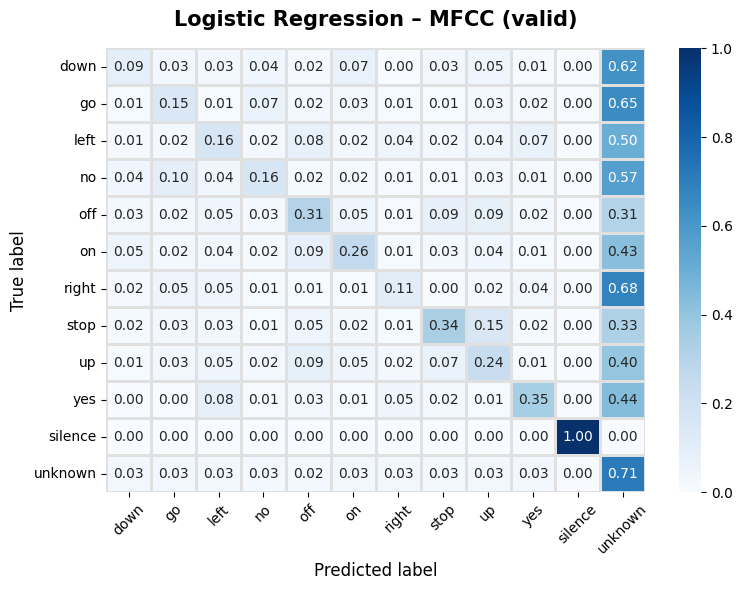

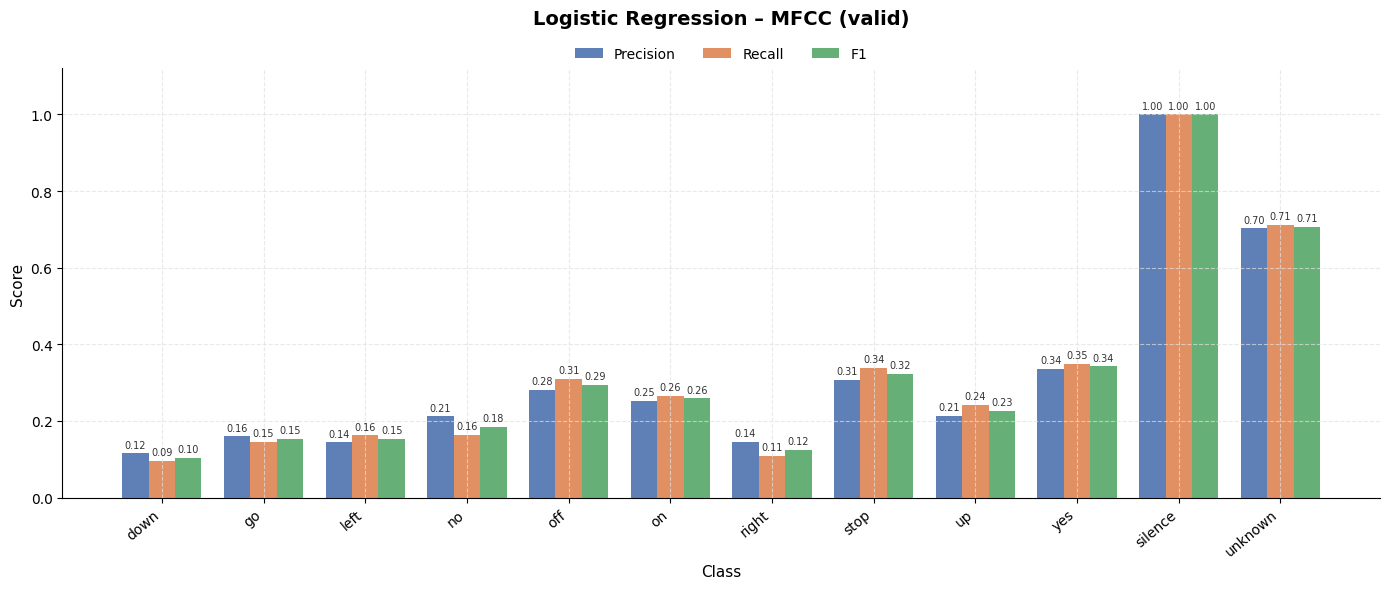

In [17]:
preds_valid = lr.predict(X_valid)
result_valid = evaluate(preds_valid, y_valid)
plot_confusion_matrix(result_valid['cm'], normalize=True, title='Logistic Regression – MFCC (valid)')
plot_per_class_metrics(y_valid, preds_valid, title='Logistic Regression – MFCC (valid)')


Accuracy: 0.5228
Macro F1: 0.2998
Weighted F1: 0.5208

Per-class report:
              precision    recall  f1-score   support

        down       0.13      0.11      0.12       253
          go       0.10      0.11      0.11       251
        left       0.18      0.19      0.18       267
          no       0.11      0.10      0.10       252
         off       0.27      0.25      0.26       262
          on       0.23      0.24      0.23       246
       right       0.13      0.12      0.12       259
        stop       0.29      0.30      0.30       249
          up       0.21      0.20      0.20       272
         yes       0.27      0.35      0.31       256
     silence       0.91      1.00      0.95        30
     unknown       0.71      0.72      0.71      4268

    accuracy                           0.52      6865
   macro avg       0.30      0.31      0.30      6865
weighted avg       0.52      0.52      0.52      6865



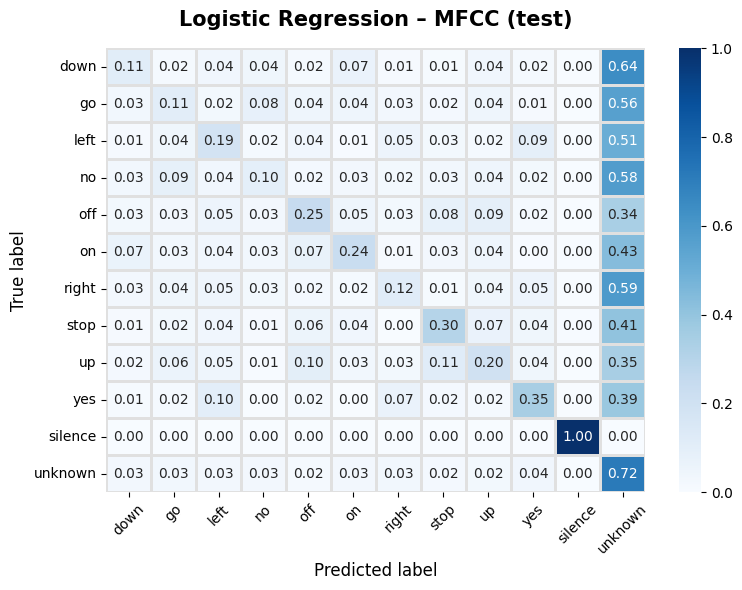

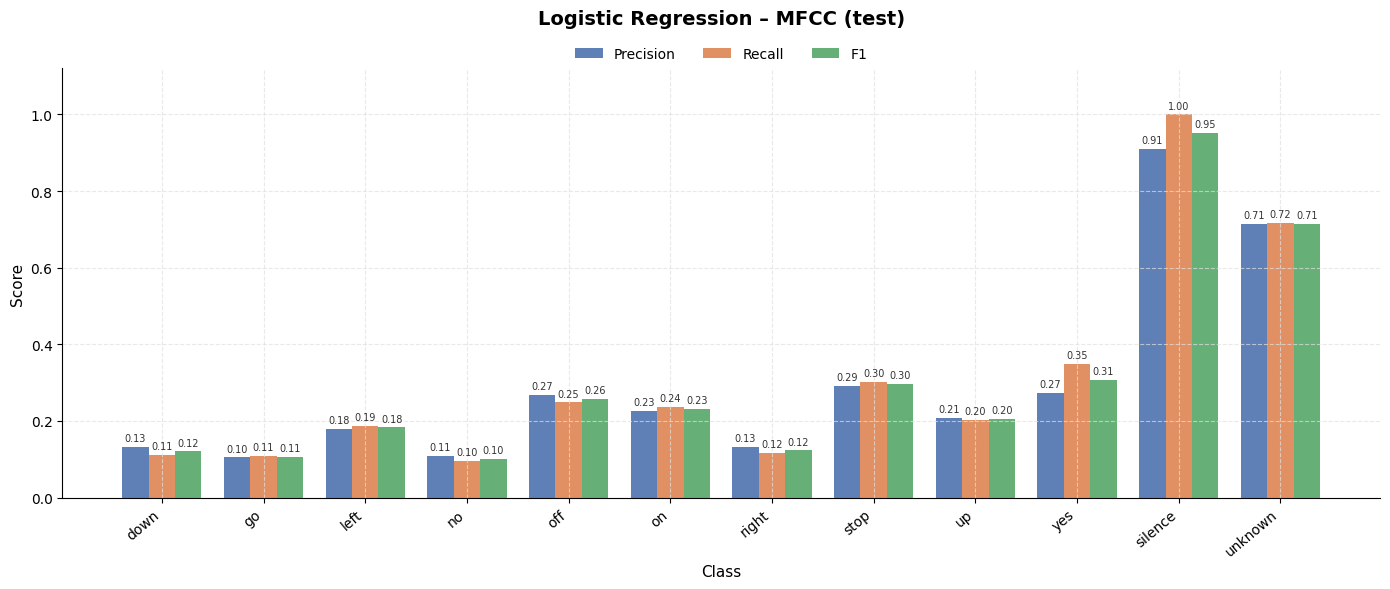

In [18]:
preds_test = lr.predict(X_test)
result_test = evaluate(preds_test, y_test)
plot_confusion_matrix(result_test['cm'], normalize=True, title='Logistic Regression – MFCC (test)')
plot_per_class_metrics(y_test, preds_test, title='Logistic Regression – MFCC (test)')